In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display plots inside Jupyter Notebook
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ============================================
# Generate Synthetic Employee Dataset
# ============================================

# Set random seed for reproducible results
np.random.seed(42)

# Number of employee records
num_records = 2000

# Generate employee data
employee_data = pd.DataFrame({
    "EmployeeID": range(1, num_records + 1),

    "Age": np.random.randint(21, 60, num_records),

    "Gender": np.random.choice(
        ["Male", "Female"],
        num_records
    ),

    "EducationLevel": np.random.choice(
        ["Bachelor", "Master", "PhD"],
        num_records,
        p=[0.5, 0.35, 0.15]
    ),

    "YearsOfExperience": np.random.randint(0, 36, num_records),

    "JobRole": np.random.choice(
        ["Developer", "Data Analyst", "Manager", "Designer", "Tester"],
        num_records
    ),

    "SkillsScore": np.random.randint(1, 11, num_records),

    "Certifications": np.random.randint(0, 11, num_records),

    "CompanyType": np.random.choice(
        ["Startup", "Medium Scale", "MNC"],
        num_records
    ),

    "WorkHoursPerWeek": np.random.randint(35, 61, num_records)
})

print("Employee data generated successfully!")

Employee data generated successfully!


In [4]:
salary = []

for i in range(num_records):

    base_salary = 250000

    # Experience
    experience_bonus = employee_data.loc[i, "YearsOfExperience"] * 30000

    # Skills
    skills_bonus = employee_data.loc[i, "SkillsScore"] * 15000

    # Certifications
    certification_bonus = employee_data.loc[i, "Certifications"] * 10000

    # Education
    education = employee_data.loc[i, "EducationLevel"]

    if education == "Bachelor":
        education_bonus = 50000
    elif education == "Master":
        education_bonus = 120000
    else:
        education_bonus = 200000

    # Company Type
    company = employee_data.loc[i, "CompanyType"]

    if company == "Startup":
        company_bonus = 30000
    elif company == "Medium Scale":
        company_bonus = 70000
    else:
        company_bonus = 120000

    # Random variation
    noise = np.random.randint(-30000, 30001)

    total_salary = (
        base_salary
        + experience_bonus
        + skills_bonus
        + certification_bonus
        + education_bonus
        + company_bonus
        + noise
    )

    salary.append(total_salary)

employee_data["Salary"] = salary

print("Salary column created successfully!")

Salary column created successfully!


In [5]:
employee_data.to_csv(
    "../data/employee_salary_dataset.csv",
    index=False
)

print("Dataset saved successfully!")

employee_data.head()

Dataset saved successfully!


,EmployeeID,Age,Gender,EducationLevel,YearsOfExperience,JobRole,SkillsScore,Certifications,CompanyType,WorkHoursPerWeek,Salary
0,1,59,Male,Bachelor,29,Tester,3,4,MNC,46,1353645
1,2,49,Female,Bachelor,7,Tester,6,5,Medium Scale,43,741773
2,3,35,Female,Master,19,Developer,8,9,Medium Scale,41,1231578
3,4,28,Male,PhD,31,Designer,9,8,MNC,46,1726596
4,5,41,Female,Bachelor,21,Data Analyst,6,7,Startup,49,1141500


In [6]:
print("Dataset Shape:", employee_data.shape)

Dataset Shape: (2000, 11)


In [7]:
employee_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         2000 non-null   int64
 1   Age                2000 non-null   int32
 2   Gender             2000 non-null   str  
 3   EducationLevel     2000 non-null   str  
 4   YearsOfExperience  2000 non-null   int32
 5   JobRole            2000 non-null   str  
 6   SkillsScore        2000 non-null   int32
 7   Certifications     2000 non-null   int32
 8   CompanyType        2000 non-null   str  
 9   WorkHoursPerWeek   2000 non-null   int32
 10  Salary             2000 non-null   int32
dtypes: int32(6), int64(1), str(4)
memory usage: 125.1 KB


In [8]:
employee_data.isnull().sum()

EmployeeID           0
Age                  0
Gender               0
EducationLevel       0
YearsOfExperience    0
JobRole              0
SkillsScore          0
Certifications       0
CompanyType          0
WorkHoursPerWeek     0
Salary               0
dtype: int64

In [9]:
print("Duplicate Records:", employee_data.duplicated().sum())

Duplicate Records: 0


In [10]:
employee_data = employee_data.drop_duplicates()

print("Duplicates Removed Successfully!")

Duplicates Removed Successfully!


In [11]:
# ============================================
# Statistical Summary
# ============================================

employee_data.describe()

,EmployeeID,Age,YearsOfExperience,SkillsScore,Certifications,WorkHoursPerWeek,Salary
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2.000000e+03
mean,1000.500000,40.358500,17.481500,5.59200,4.966500,47.663500,1.078296e+06
std,577.494589,11.359379,10.300228,2.85878,3.111948,7.406868,3.219390e+05
min,1.000000,21.000000,0.000000,1.00000,0.000000,35.000000,3.518090e+05
25%,500.750000,30.000000,9.000000,3.00000,2.000000,41.000000,8.205425e+05
50%,1000.500000,41.000000,17.000000,6.00000,5.000000,48.000000,1.076736e+06
75%,1500.250000,50.000000,26.000000,8.00000,8.000000,54.000000,1.347792e+06
max,2000.000000,59.000000,35.000000,10.00000,10.000000,60.000000,1.783308e+06


In [13]:
# ============================================
# Average Salary by Education
# ============================================

employee_data.groupby("EducationLevel")["Salary"].mean()

EducationLevel
Bachelor    1.033190e+06
Master      1.098931e+06
PhD         1.181505e+06
Name: Salary, dtype: float64

In [14]:
# ============================================
# Average Salary by Job Role
# ============================================

employee_data.groupby("JobRole")["Salary"].mean()

JobRole
Data Analyst    1.107702e+06
Designer        1.075084e+06
Developer       1.063083e+06
Manager         1.079988e+06
Tester          1.067987e+06
Name: Salary, dtype: float64

In [15]:
# ============================================
# Average Salary by Company Type
# ============================================

employee_data.groupby("CompanyType")["Salary"].mean()

CompanyType
MNC             1.128294e+06
Medium Scale    1.064796e+06
Startup         1.040113e+06
Name: Salary, dtype: float64

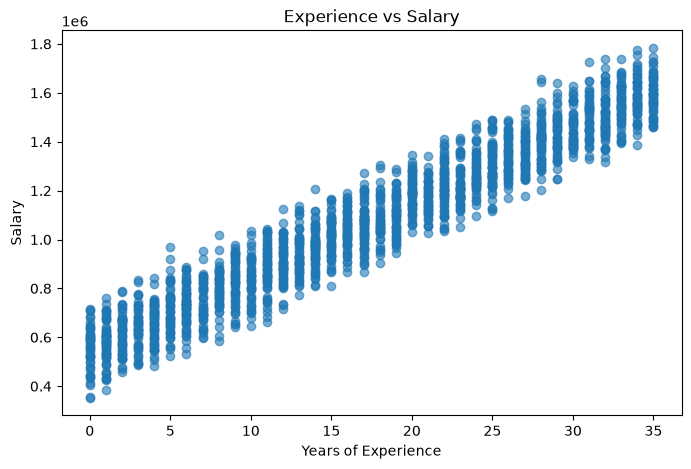

In [16]:
# ============================================
# Scatter Plot: Experience vs Salary
# ============================================

plt.figure(figsize=(8,5))

plt.scatter(
    employee_data["YearsOfExperience"],
    employee_data["Salary"],
    alpha=0.6
)

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.savefig("../images/scatter_plot.png")

plt.show()

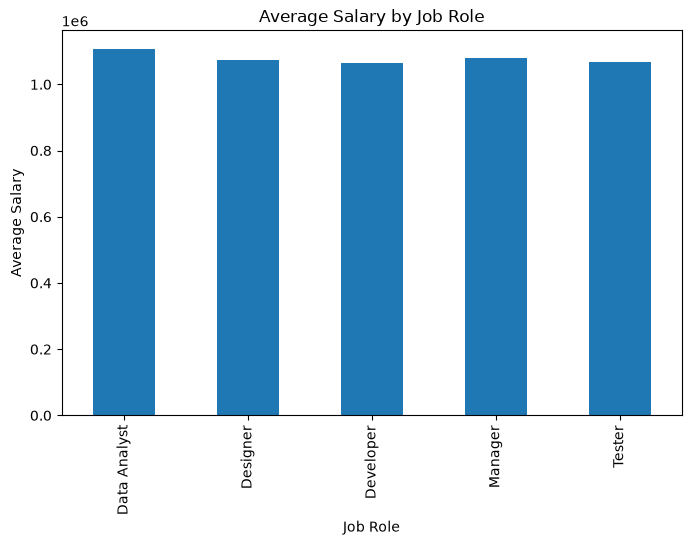

In [17]:
# ============================================
# Average Salary by Job Role
# ============================================

plt.figure(figsize=(8,5))

employee_data.groupby("JobRole")["Salary"].mean().plot(kind="bar")

plt.title("Average Salary by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Average Salary")

plt.savefig("../images/bar_chart.png")

plt.show()

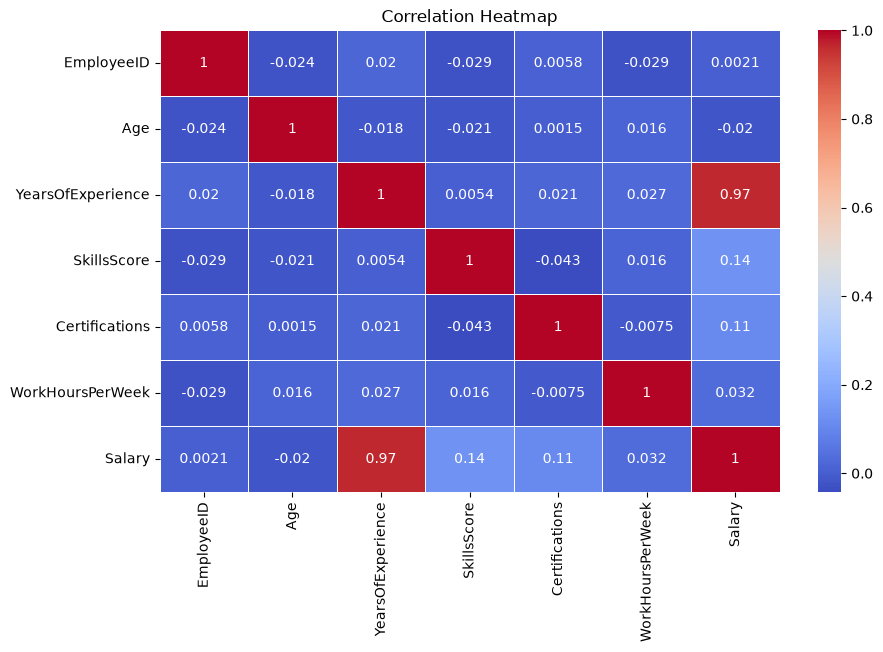

In [18]:
# ============================================
# Correlation Heatmap
# ============================================

plt.figure(figsize=(10,6))

corr = employee_data.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.savefig("../images/heatmap.png")

plt.show()

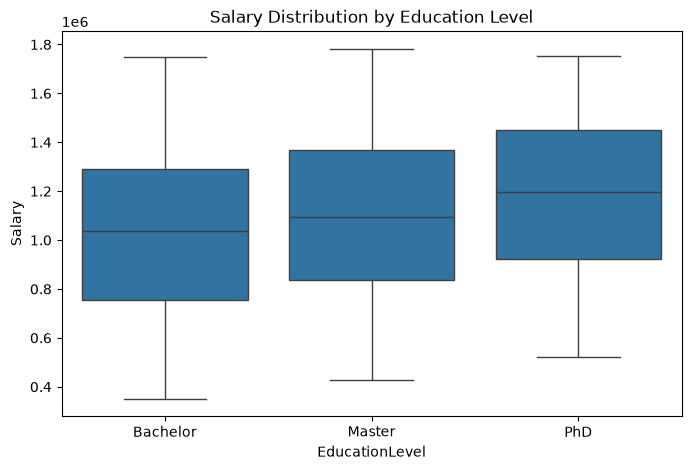

In [19]:
# ============================================
# Salary Distribution by Education Level
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="EducationLevel",
    y="Salary",
    data=employee_data
)

plt.title("Salary Distribution by Education Level")

plt.savefig("../images/boxplot.png")

plt.show()

In [20]:
# ============================================
# Convert Categorical Data into Numerical Data
# ============================================

employee_data_ml = pd.get_dummies(
    employee_data,
    columns=["Gender", "EducationLevel", "JobRole", "CompanyType"],
    drop_first=True
)

print("Categorical columns converted successfully!")

employee_data_ml.head()

Categorical columns converted successfully!


,EmployeeID,Age,YearsOfExperience,SkillsScore,Certifications,WorkHoursPerWeek,Salary,Gender_Male,EducationLevel_Master,EducationLevel_PhD,JobRole_Designer,JobRole_Developer,JobRole_Manager,JobRole_Tester,CompanyType_Medium Scale,CompanyType_Startup
0,1,59,29,3,4,46,1353645,True,False,False,False,False,False,True,False,False
1,2,49,7,6,5,43,741773,False,False,False,False,False,False,True,True,False
2,3,35,19,8,9,41,1231578,False,True,False,False,True,False,False,True,False
3,4,28,31,9,8,46,1726596,True,False,True,True,False,False,False,False,False
4,5,41,21,6,7,49,1141500,False,False,False,False,False,False,False,False,True


In [21]:
# ============================================
# Features and Target
# ============================================

X = employee_data_ml.drop(["EmployeeID", "Salary"], axis=1)

y = employee_data_ml["Salary"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (2000, 14)
Target Shape : (2000,)


In [22]:
# ============================================
# Train Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (1600, 14)
Testing Data : (400, 14)


In [23]:
# ============================================
# Linear Regression Model
# ============================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [24]:
# ============================================
# Predict Salary
# ============================================

y_pred = model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [25]:
# ============================================
# Model Evaluation
# ============================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))
print("R² Score:", round(r2,4))

Mean Absolute Error (MAE): 14524.13
Root Mean Squared Error (RMSE): 16862.35
R² Score: 0.9969


In [26]:
# ============================================
# Take User Input
# ============================================

age = int(input("Enter Age: "))
gender = input("Enter Gender (Male/Female): ")
education = input("Enter Education Level (Bachelor/Master/PhD): ")
experience = int(input("Enter Years of Experience: "))
job_role = input("Enter Job Role (Developer/Data Analyst/Manager/Designer/Tester): ")
skills = int(input("Enter Skills Score (1-10): "))
certifications = int(input("Enter Number of Certifications: "))
company = input("Enter Company Type (Startup/Medium Scale/MNC): ")
work_hours = int(input("Enter Work Hours Per Week: "))

Enter Age:  28
Enter Gender (Male/Female):  Female
Enter Education Level (Bachelor/Master/PhD):  Master
Enter Years of Experience:  5
Enter Job Role (Developer/Data Analyst/Manager/Designer/Tester):  Developer
Enter Skills Score (1-10):  8
Enter Number of Certifications:  3
Enter Company Type (Startup/Medium Scale/MNC):  MNC
Enter Work Hours Per Week:  40


In [27]:
# ============================================
# Create User Data
# ============================================

user_data = pd.DataFrame({
    "Age": [age],
    "YearsOfExperience": [experience],
    "SkillsScore": [skills],
    "Certifications": [certifications],
    "WorkHoursPerWeek": [work_hours],
    "Gender": [gender],
    "EducationLevel": [education],
    "JobRole": [job_role],
    "CompanyType": [company]
})

In [28]:
# ============================================
# Convert User Data
# ============================================

user_data = pd.get_dummies(user_data)

# Match training columns
user_data = user_data.reindex(columns=X.columns, fill_value=0)

user_data

,Age,YearsOfExperience,SkillsScore,Certifications,WorkHoursPerWeek,Gender_Male,EducationLevel_Master,EducationLevel_PhD,JobRole_Designer,JobRole_Developer,JobRole_Manager,JobRole_Tester,CompanyType_Medium Scale,CompanyType_Startup
0,28,5,8,3,40,0,True,0,0,True,0,0,0,0


In [29]:
# ============================================
# Predict Salary
# ============================================

predicted_salary = model.predict(user_data)

print(f"\nPredicted Employee Salary: ₹{predicted_salary[0]:,.2f}")


Predicted Employee Salary: ₹790,467.18


In [30]:
# ============================================
# Save Model
# ============================================

import joblib

joblib.dump(model, "../salary_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
